# Representasi TF-IDF dan Reduksi Dimensi Data Berita

Setelah data berita berhasil dikumpulkan dan melalui tahap preprocessing, data teks perlu diubah menjadi bentuk numerik agar dapat diolah lebih lanjut. Pada tahap ini, teks berita direpresentasikan menggunakan TF-IDF (Term Frequency–Inverse Document Frequency) untuk memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya dalam dokumen.

Data hasil TF-IDF memiliki jumlah fitur yang cukup banyak karena setiap kata yang terdapat dalam vocabulary menjadi sebuah fitur. Oleh karena itu, dilakukan reduksi dimensi menggunakan PCA (Principal Component Analysis) untuk mengurangi jumlah fitur dengan tetap mempertahankan sebagian besar informasi dari data.

Tahapan yang dilakukan meliputi pembentukan vocabulary, representasi teks menggunakan TF-IDF, dan reduksi dimensi menggunakan PCA.

### Install Library NLTK

In [3]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('words')

[nltk_data] Downloading package punkt to C:\Users\triad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\triad/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package words to C:\Users\triad/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [4]:
import pandas as pd

df = pd.read_csv("dataset_berita.csv")
print(df.shape)
df.head()

(200, 3)


,id,isi_berita,label
0,1,Jepang - Austin Krajicek-Nikola Mektic berhasi...,sport
1,2,Jorge Martin sedang memperjuangkan titel juara...,sport
2,3,Rider Indonesia Veda Ega Pratama balapan di Ma...,sport
3,4,"Pelatih speed tim panjat tebing, Fitriyani, me...",sport
4,5,Pertamina Grand Prix of Indonesia 2026 sudah m...,sport


## Preprocessing Data

Data berita yang telah dikumpulkan terlebih dahulu dilakukan preprocessing. Pada tahap cleaning, teks diubah menjadi huruf kecil, URL, emoji, tanda baca, dan angka dihapus, serta spasi yang berlebih dirapikan. Setelah itu, teks diubah menjadi token atau kata-kata menggunakan proses tokenisasi.

In [6]:
import re
import emoji

def cleaning(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['isi_bersih'] = df['isi_berita'].apply(cleaning)
df[['isi_berita', 'isi_bersih']].head()

,isi_berita,isi_bersih
0,Jepang - Austin Krajicek-Nikola Mektic berhasi...,jepang austin krajicek nikola mektic berhasil ...
1,Jorge Martin sedang memperjuangkan titel juara...,jorge martin sedang memperjuangkan titel juara...
2,Rider Indonesia Veda Ega Pratama balapan di Ma...,rider indonesia veda ega pratama balapan di ma...
3,"Pelatih speed tim panjat tebing, Fitriyani, me...",pelatih speed tim panjat tebing fitriyani meng...
4,Pertamina Grand Prix of Indonesia 2026 sudah m...,pertamina grand prix of indonesia sudah melahi...


In [7]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['isi_bersih'].apply(word_tokenize)
df[['isi_bersih', 'tokens']].head()

,isi_bersih,tokens
0,jepang austin krajicek nikola mektic berhasil ...,"[jepang, austin, krajicek, nikola, mektic, ber..."
1,jorge martin sedang memperjuangkan titel juara...,"[jorge, martin, sedang, memperjuangkan, titel,..."
2,rider indonesia veda ega pratama balapan di ma...,"[rider, indonesia, veda, ega, pratama, balapan..."
3,pelatih speed tim panjat tebing fitriyani meng...,"[pelatih, speed, tim, panjat, tebing, fitriyan..."
4,pertamina grand prix of indonesia sudah melahi...,"[pertamina, grand, prix, of, indonesia, sudah,..."


Selanjutnya dilakukan stopword removal untuk menghapus kata-kata yang dianggap kurang memiliki informasi penting. Stopword yang digunakan berasal dari Sastrawi dan ditambahkan beberapa kata secara manual.

In [9]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import words as english_words

stopword_factory = StopWordRemoverFactory()
indo_stopwords = set(stopword_factory.get_stop_words())
factory = StemmerFactory()
stemmer = factory.create_stemmer()
english_vocab = set(w.lower() for w in english_words.words())

tambahan_stopwords = {"kali", "mana", "hal", "tim", "era", "pun", "apa", "dan", "dari", "akan", "yang", "saya"}
indo_stopwords = indo_stopwords.union(tambahan_stopwords)

def kata_asing(tokens):
    asing = []
    for t in tokens:
        if t in indo_stopwords:
            continue
        if len(t) <= 3:
            continue
        stem = stemmer.stem(t)
        if t in english_vocab and stem == t:
            asing.append(t)
    return asing

contoh = df['tokens'].iloc[0]
print(kata_asing(contoh))

['austin', 'ganda', 'japan', 'open', 'sport', 'ganda', 'japan', 'open']


In [10]:
def remove_stopwords(tokens):
    return [t for t in tokens if t not in indo_stopwords]

df['tokens_no_stopword'] = df['tokens'].apply(remove_stopwords)
df[['tokens', 'tokens_no_stopword']].head()

,tokens,tokens_no_stopword
0,"[jepang, austin, krajicek, nikola, mektic, ber...","[jepang, austin, krajicek, nikola, mektic, ber..."
1,"[jorge, martin, sedang, memperjuangkan, titel,...","[jorge, martin, sedang, memperjuangkan, titel,..."
2,"[rider, indonesia, veda, ega, pratama, balapan...","[rider, indonesia, veda, ega, pratama, balapan..."
3,"[pelatih, speed, tim, panjat, tebing, fitriyan...","[pelatih, speed, panjat, tebing, fitriyani, me..."
4,"[pertamina, grand, prix, of, indonesia, sudah,...","[pertamina, grand, prix, of, indonesia, melahi..."


Setelah stopword dihapus, dilakukan stemming menggunakan stemmer Bahasa Indonesia untuk mengubah kata menjadi bentuk dasarnya. Dari proses ini dihasilkan kolom tokens_final yang digunakan pada tahap berikutnya.

In [11]:
def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

hasil_stem = []
total = len(df)

for i, tokens in enumerate(df['tokens_no_stopword'], 1):
    hasil_stem.append(stem_tokens(tokens))
    print(f"\rStemming progress: {i}/{total}", end="", flush=True)

df['tokens_final'] = hasil_stem

print("\nSelesai stemming")
df[['tokens_no_stopword', 'tokens_final']].head()

Stemming progress: 200/200
Selesai stemming


,tokens_no_stopword,tokens_final
0,"[jepang, austin, krajicek, nikola, mektic, ber...","[jepang, austin, krajicek, nikola, mektic, has..."
1,"[jorge, martin, sedang, memperjuangkan, titel,...","[jorge, martin, sedang, juang, titel, juara, d..."
2,"[rider, indonesia, veda, ega, pratama, balapan...","[rider, indonesia, veda, ega, pratama, balap, ..."
3,"[pelatih, speed, panjat, tebing, fitriyani, me...","[latih, speed, panjat, tebing, fitriyani, ungk..."
4,"[pertamina, grand, prix, of, indonesia, melahi...","[pertamina, grand, prix, of, indonesia, lahir,..."


## Pembentukan Vocabulary

Setelah preprocessing selesai, seluruh kata dari tokens_final dikumpulkan dan kata yang sama hanya dihitung satu kali. Hasilnya terdapat 5.108 kata unik yang digunakan sebagai vocabulary.

In [14]:
semua_kata = [kata for tokens in df['tokens_final'] for kata in tokens]
reserved_words = {"id", "label"}

vocabulary = sorted(set(
    kata for kata in semua_kata 
    if kata not in reserved_words
))
print(f"Jumlah kata unik setelah filter: {len(vocabulary)}")
print(vocabulary[:30])

Jumlah kata unik setelah filter: 5108
['a', 'aadi', 'abad', 'abai', 'abal', 'abang', 'abdi', 'abdul', 'abdullah', 'abdurrahman', 'abe', 'abipraya', 'abruzzo', 'absen', 'abu', 'abuan', 'ac', 'academy', 'acara', 'acas', 'acceleration', 'accountant', 'accounting', 'accuracy', 'acd', 'aceh', 'acosta', 'action', 'acu', 'acung']


## Representasi Berita dengan TF-IDF

TF-IDF digunakan untuk memberikan bobot pada setiap kata berdasarkan seberapa penting kata tersebut dalam suatu berita. Pada proses ini terdapat dua perhitungan utama, yaitu TF (Term Frequency) dan IDF (Inverse Document Frequency).

Term Frequency (TF):
$$
TF(t,d) = \frac{f(t,d)}{\sum_{t' \in d} f(t',d)}
$$

Keterangan:
* $t$ = kata yang dihitung
* $d$ = dokumen/berita
* $f(t,d)$ = jumlah kemunculan kata $t$ dalam dokumen $d$
* Penyebut = jumlah seluruh kata dalam dokumen

Inverse Document Frequency (IDF):
$$
IDF(t) = \log\left(\frac{N}{df(t)}\right)
$$

Keterangan:
* $N$ = jumlah seluruh dokumen
* $df(t)$ = jumlah dokumen yang mengandung kata t

Kemudian nilai TF dan IDF dikalikan untuk mendapatkan bobot TF-IDF:
$$TFIDF(t,d)=TF(t,d)×IDF(t)$$

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

df['teks_final'] = df['tokens_final'].apply(lambda tokens: ' '.join(tokens))

vectorizer = CountVectorizer(binary=True, vocabulary=vocabulary)
onehot_matrix = vectorizer.fit_transform(df['teks_final'])

onehot_df = pd.DataFrame(onehot_matrix.toarray(), columns=vectorizer.get_feature_names_out())
onehot_df.insert(0, 'id', df['id'].values)
onehot_df['label'] = df['label'].values

print(onehot_df.shape)
onehot_df.head()

(200, 5110)


,id,a,aadi,abad,abai,abal,abang,abdi,abdul,abdullah,...,zhang,zidane,zig,zona,zone,zones,zoom,zulhas,zulkifli,label
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(vocabulary=vocabulary)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['teks_final'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.insert(0, 'id', df['id'].values)
tfidf_df['label'] = df['label'].values

print(tfidf_df.shape)
tfidf_df.head()

(200, 5110)


,id,a,aadi,abad,abai,abal,abang,abdi,abdul,abdullah,...,zhang,zidane,zig,zona,zone,zones,zoom,zulhas,zulkifli,label
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport


Teks yang telah melalui preprocessing kemudian digabungkan kembali menjadi teks menggunakan tokens_final. Selanjutnya, TF-IDF digunakan untuk mengubah setiap berita menjadi representasi numerik berdasarkan bobot kepentingan setiap kata dalam dokumen. Hasil representasi menghasilkan 200 berita dengan 5.108 fitur kata.

In [17]:
contoh_doc = tfidf_df.drop(columns=['id', 'label']).iloc[0]
print(contoh_doc.sort_values(ascending=False).head(10))

japan       0.358252
krajicek    0.358252
mektic      0.358252
open        0.288097
artikel     0.255477
ganda       0.255477
putra       0.189728
austin      0.179126
nikola      0.179126
sabet       0.179126
Name: 0, dtype: float64


Pada berita pertama, beberapa kata dengan nilai TF-IDF tertinggi adalah japan, krajicek dan mektic. Hal ini menunjukkan bahwa kata-kata tersebut memiliki bobot yang cukup tinggi pada dokumen tersebut dibandingkan kata lainnya.

In [18]:
tfidf_df.to_csv("tfidf_berita.csv", index=False)
print("Selesai! Tersimpan sebagai tfidf_berita.csv")

Selesai! Tersimpan sebagai tfidf_berita.csv


Hasil TF-IDF kemudian disimpan dalam file tfidf_berita.csv untuk digunakan pada proses selanjutnya.

## Reduksi Dimensi dengan PCA

Data hasil TF-IDF kemudian digunakan sebagai input untuk PCA (Principal Component Analysis). Sebelum PCA, data memiliki ukuran 200 × 5.108, yaitu 200 berita dengan 5.108 fitur.

In [19]:
X = tfidf_df.drop(columns=['id', 'label']).values
y = tfidf_df['label'].values

print("Shape sebelum PCA:", X.shape)

Shape sebelum PCA: (200, 5108)


PCA digunakan untuk mengurangi jumlah fitur dengan mempertahankan informasi utama dari data. Pada notebook, jumlah komponen ditentukan berdasarkan cumulative explained variance sebesar 90%. Hasilnya, dibutuhkan 137 komponen dari 5.108 dimensi awal.

In [22]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA()
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Jumlah komponen untuk menjelaskan 90% variansi: {n_components_90}")
print(f"Total dimensi awal: {X.shape[1]}")

Jumlah komponen untuk menjelaskan 90% variansi: 139
Total dimensi awal: 5108


In [23]:
pca = PCA(n_components=n_components_90)
X_reduced = pca.fit_transform(X)

print("Shape setelah PCA:", X_reduced.shape)

pca_df = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(X_reduced.shape[1])])
pca_df.insert(0, 'id', tfidf_df['id'].values)
pca_df['label'] = y

pca_df.head()

Shape setelah PCA: (200, 139)


,id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139,label
0,1,0.016310,0.064040,-0.003596,0.058287,0.034701,-0.011416,-0.013548,-0.049478,-0.012545,...,0.030304,0.038745,0.027398,0.023805,-0.028052,-0.003597,0.016633,0.064700,-0.006247,sport
1,2,0.335563,-0.048594,0.026808,0.028114,-0.140747,0.024754,-0.016208,-0.025431,0.007980,...,0.059164,-0.053914,-0.069388,-0.057029,0.007123,-0.054663,-0.008188,0.054430,-0.075545,sport
2,3,0.163250,0.052259,-0.017724,0.060311,0.330874,-0.018232,-0.012890,-0.057679,0.031286,...,-0.022419,0.091648,0.052644,0.042707,0.075697,-0.059457,-0.061724,0.029606,0.002340,sport
3,4,-0.009962,0.294924,0.007640,-0.004036,-0.008824,-0.019960,0.017993,0.116127,-0.044190,...,-0.030776,0.086397,-0.045490,-0.104737,-0.228806,-0.012939,0.017881,0.035670,-0.041894,sport
4,5,0.524751,-0.076431,0.015991,-0.011711,-0.117077,-0.012359,0.005967,-0.252379,0.178608,...,-0.051039,-0.054479,-0.077658,-0.052478,-0.046393,0.052913,0.023458,-0.026328,0.042178,sport


Setelah dilakukan PCA, ukuran data berubah menjadi 200 × 139. Setiap fitur hasil reduksi direpresentasikan sebagai PC1, PC2, hingga PC144.

In [24]:
pca_df.to_csv("pca_berita.csv", index=False)
print("Selesai! Tersimpan sebagai pca_berita.csv")

Selesai! Tersimpan sebagai pca_berita.csv


Hasil akhir PCA kemudian disimpan dalam file pca_berita.csv.

### Visualisasi PCA

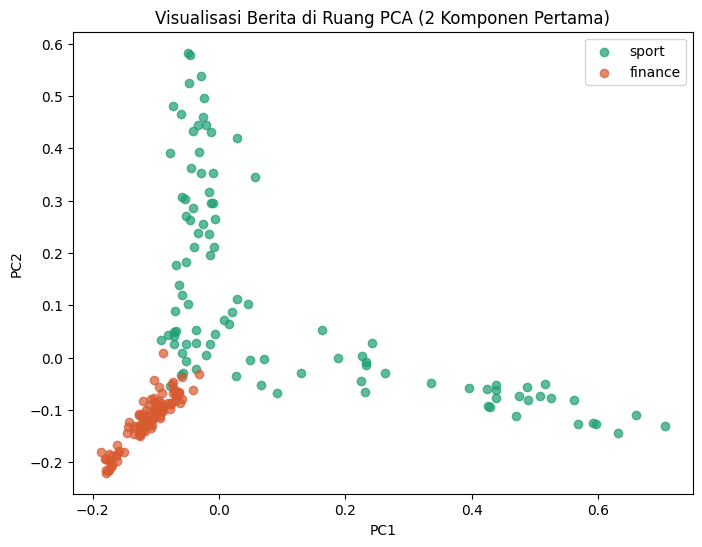

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for label_value, warna in zip(['sport', 'finance'], ['#1D9E75', '#D85A30']):
    subset = pca_df[pca_df['label'] == label_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=label_value, alpha=0.7, color=warna)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi Berita di Ruang PCA (2 Komponen Pertama)')
plt.legend()
plt.show()

Grafik menunjukkan bahwa berita sport dan finance memiliki pola teks yang berbeda. Berita finance cenderung berkumpul di satu area, sedangkan berita sport lebih menyebar. Artinya, isi atau karakteristik kata yang digunakan pada kedua kategori berita cukup berbeda.